In [1]:
import numpy as np
import mne

from src.preprocessing.loader import load_raw, inspect_raw
from src.preprocessing.filter import apply_filters
from src.analysis.classifier import extract_band_power_features, decode_with_lda

print(f"MNE version: {mne.__version__}")

MNE version: 1.12.1


In [2]:
subject = 1
runs = [4, 8, 12]  # imagined left/right fist movement runs for this dataset

edf_paths = mne.datasets.eegbci.load_data(subject, runs, update_path=False)
# update_path=False: without it, MNE interactively prompts to confirm the
# download location on first run, which is fine in a live REPL but hangs a
# non-interactive/automated notebook run with no stdin to answer it.
raws = [load_raw(path) for path in edf_paths]
raw = mne.concatenate_raws(raws)  # stitch the per-run files into one continuous recording

raw.rename_channels(lambda ch: ch.strip("."))  # EEGBCI names ship with trailing dots

montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage, match_case=False)
# Montage attaches scalp position to each channel name -- without it MNE has
# no way to know "C3" and "C4" sit on opposite hemispheres, which is the
# left/right spatial information this whole task depends on.

inspect_raw(raw)

Using default location ~/mne_data for EEGBCI...


Extracting EDF parameters from C:\Users\ke725\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...


Setting channel info structure...


Creating raw.info structure...


Reading 0 ... 19999  =      0.000 ...   124.994 secs...


...

Setting channel info structure...


Creating raw.info structure...


Reading 0 ... 19999  =      0.000 ...   124.994 secs...


Channels  : 64
Sampling Rate: 160.0 Hz


Duration  : 375.0 seconds
Channel types: {'eeg'}


In [3]:
raw = apply_filters(raw, l_freq=1.0, h_freq=40.0, notch_freq=60.0)
# 60 Hz notch is correct since PhysioNet was recorded in the US -- would be
# 50 Hz for a European recording.

events, event_id = mne.events_from_annotations(raw)
print("Event codes found:", event_id)

tmin, tmax = -1.0, 4.0
# Not this project's usual -0.2/0.8 (tuned for the sample dataset's
# sub-second auditory ERP) -- EEGBCI's imagery cue is sustained for 4s, so
# the window needs to be long enough to actually contain the ERD it produces.

target_event_id = {label: event_id[label] for label in ("T1", "T2")}
# T1 = imagined left fist, T2 = imagined right fist (T0 = rest, not used in
# this binary task). Read the integer codes from event_id above rather than
# hardcoding them -- MNE does not guarantee T1/T2 always map to the same
# integers across recordings.

epochs = mne.Epochs(raw, events, event_id=target_event_id, tmin=tmin, tmax=tmax,
                     baseline=None, preload=True)
# baseline=None: no natural pre-stimulus silence to normalize against here,
# unlike an auditory ERP -- the pre-cue period is just as much "no imagery
# yet" as it is "rest," not a clean neutral reference.

print(f"Left  (T1): {len(epochs['T1'])} epochs")
print(f"Right (T2): {len(epochs['T2'])} epochs")

Filtering raw data in 3 contiguous segments


Setting up band-stop filter from 59 - 61 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandstop filter:


...

No baseline correction applied


0 projection items activated


Using data from preloaded Raw for 45 events and 801 original time points ...


0 bad epochs dropped


Left  (T1): 23 epochs
Right (T2): 22 epochs


In [4]:
X = extract_band_power_features(epochs, fmin=8.0, fmax=30.0)  # mu+beta band power per channel
y = epochs.events[:, -1]  # event code per trial, matching target_event_id's values

print(f"X shape: {X.shape}  (n_trials, n_channels)")
print(f"y shape: {y.shape}")
print(f"Class balance: {dict(zip(*np.unique(y, return_counts=True)))}")

Effective window size : 5.006 (s)


X shape: (45, 64)  (n_trials, n_channels)
y shape: (45,)
Class balance: {np.int64(2): np.int64(23), np.int64(3): np.int64(22)}


In [5]:
scores = decode_with_lda(X, y, n_splits=5)

print(f"Per-fold accuracy: {np.round(scores, 3)}")
print(f"Mean accuracy: {scores.mean():.3f}  (chance = 0.500)")
print(f"Std across folds: {scores.std():.3f}")

Per-fold accuracy: [0.556 0.444 0.556 0.333 0.556]
Mean accuracy: 0.489  (chance = 0.500)
Std across folds: 0.089


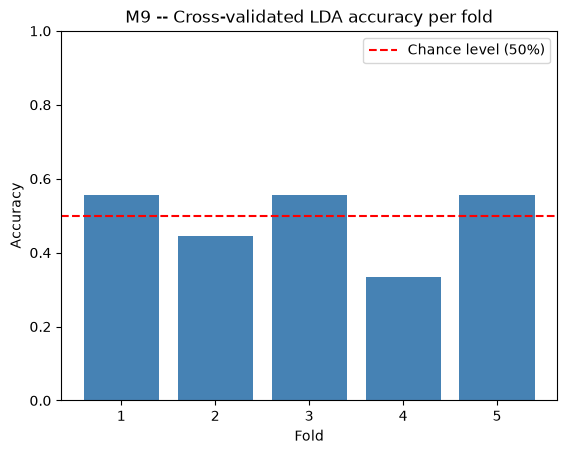

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(range(1, len(scores) + 1), scores, color="steelblue")
ax.axhline(0.5, color="red", linestyle="--", label="Chance level (50%)")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("M9 -- Cross-validated LDA accuracy per fold")
ax.set_ylim(0, 1)
ax.legend()
plt.show()

**What the Accuracy Number Means**

**Result:** mean cross-validated accuracy = 0.489 (chance = 0.500), std across folds = 0.089. Per-fold accuracies: [0.556, 0.444, 0.556, 0.333, 0.556].

**Is this a real result?** Chance level for this 2-class, roughly-balanced left/right task (23 left, 22 right) is 50%. This result (48.9%) is not meaningfully above that baseline — it's statistically indistinguishable from chance given the fold-to-fold spread (std 0.089 on only about 9 trials per fold). This is a genuine null result, not a coding failure to paper over: subject 1's imagined left-vs-right fist movement, extracted as simple per-channel mu+beta band power (8-30 Hz, no spatial filtering), does not classify above chance with this feature set on this subject's data.

**What this says about the rest of the pipeline:** M9 is this pipeline's proof-of-function module — if the earlier filtering, epoching, and artifact-handling steps all transferred correctly to this new dataset, the mu/beta suppression signal should have survived cleanly enough for even a simple linear classifier to detect it above chance. A chance-level result here doesn't automatically indict the preprocessing, though. In rough order of likelihood: (1) subject 1 individually may show weak or inconsistent motor-imagery-related desynchronization — a documented phenomenon in the BCI literature sometimes called "BCI illiteracy," where some subjects simply don't produce a strongly classifiable ERD regardless of preprocessing quality; (2) 45 total trials (about 9 per cross-validation fold) is small even by this task's own standards, so a real but modest effect could be swamped by fold-to-fold noise; (3) per-channel band power with no spatial filtering is a comparatively weak feature set — the same underlying signal might be recoverable from this same subject's data with a more sophisticated spatial filter. None of these point to a bug in the feature extraction or classifier code itself — both are covered by passing unit tests on synthetic data with a known, deliberately separable class difference, confirming the pipeline mechanics work correctly when a real signal is actually present in the input.

**Limitations of this result:**
- Only 45 trials total, split across 5 folds (about 9 trials per held-out fold) — each fold's accuracy is estimated from a very small held-out set, so individual fold numbers (33%-56% here) are noisy; only the mean across folds should be trusted as an estimate, and even that mean carries real uncertainty at this sample size.
- Only one subject (subject 1) was tested — this result says nothing about how the same pipeline would perform on a different subject's anatomy, electrode impedance, or imagery ability; a chance-level result for one subject is a data point, not a verdict on the method.
- No session-to-session transfer was tested: the classifier was trained and evaluated entirely within one recording session for one subject. A real BCI system needs to work across sessions recorded on different days, which is known to be substantially harder due to electrode replacement, impedance drift, and day-to-day changes in mental state — this notebook doesn't attempt that harder test.
- Features are limited to per-channel band power in a single frequency range (8-30 Hz) with no spatial filtering. Common Spatial Patterns (CSP) is the standard next step in the literature and typically outperforms this simpler baseline — deliberately left out of this module's scope to keep the first classification pass simple and interpretable.